# iTelescope premium image set processing, the easier way


**Author: Dave Strickland**

**Version: 0.5.2-alpha1**

This notebook illustrates how to process a premium image set from iTelescope using the AstroPhotography package. The python environment used corresponds to a miniconda emvironment `ap-env.yml`.

The example dataset used is the iTelescope Plan-20 premium dataset of the M101 supernova [SN 2023 ixf](https://en.wikipedia.org/wiki/SN_2023ixf). Note that these files are not provided with this package. However the notebook should work with your own files if you specify a valid fits-file containing directory at the prompt below.

The processing mirrors that of the `itelescope_premium_the_hard_way.piynb` notebook, except using the `ApProcess` class. Although all of the processing stages allow many user-controlled options the default values will be used in this example.

The processing stages consists of:

1. Creating an `ApProcess` instance to perform the processing. Using the same instance for multiple processing stages on the same set of files is recommended, and simplfies identifying which images to process.
2. (To be added later) Optional bad pixel, bad column and bad row removal in the cases where the input images still have such artifacts. This is common in the iTelescope Premium image sets, where their calibration does not remove all artifacts.
3. Finding stars in the image to allow later astrometric solution finding and image quality checking.
4. Astrometric solutions using Astrometry.net
5. Resampling and stacking of multiple images onto a common footprint to create a final image in each available band..
6. Three color image composite creation using images from  mutliple bands.

## Notebook environment setup

In [1]:
import os
import pathlib
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import math
import subprocess
import shlex
import shutil

from ccdproc import ImageFileCollection
from astropy.table import Table
from astropy import wcs
import astropy
from astropy.io import fits

import AstroPhotography as ap

In [2]:
def print_module_version(mod):
    """
    Convenience function to pretty-print Python module mod version.

    Arguments:
        mod {module} -- Imported Python module

    Returns:
        str -- module nam
e and version
    """
    print(f"Using module {mod.__name__:30s}  version: {mod.__version__}")
    return

In [3]:
# Get Version information
print(f'Python version: {sys.version}')
print_module_version(np)
print_module_version(matplotlib)
print_module_version(astropy)
print_module_version(ap)

Python version: 3.10.13 | packaged by conda-forge | (main, Dec 23 2023, 15:36:39) [GCC 12.3.0]
Using module numpy                           version: 1.26.3
Using module matplotlib                      version: 3.8.2
Using module astropy                         version: 6.0.0
Using module AstroPhotography                version: 0.5.2


In [4]:
# Enable inline plotting for graphics
# %matplotlib inline
# Set default figure size to be larger
# this may only work in matplotlib 2.0+!
from IPython.core.interactiveshell import InteractiveShell
matplotlib.rcParams['figure.figsize'] = [10.0, 6.0]
# Enable multiple outputs from jupyter cells
InteractiveShell.ast_node_interactivity = "all"

# Basic Pipeline Processing

## Create an ApProcess instance

For convenience we'll also change into the directory containing the files we intend to process.

In [5]:
default_dir = '/old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline'
print(f'Default directory for input files: {default_dir}')

print('Enter the path to the directory containing the premium image set (or return for the default): ')
wdir = input('Image set path:').strip() or default_dir
try:
    os.chdir(wdir.strip())
    print('Switched directory to ' + os.getcwd())
except:
    print(f'Error, os.chdir threw an exception changing to {wdir}')
    print('Check that the path you supplied is a valid filesystem path.')
    raise

Default directory for input files: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
Enter the path to the directory containing the premium image set (or return for the default): 


Image set path: 


Switched directory to /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline


In [6]:
# Choose the logging level.
loglevel = 'DEBUG'
processor = ap.ApProcess(loglevel)

## Star Detection and Astrometry

At the end of this stage we should have valid astrometric solutions, in the form of valid WCS coordinate headers,
added to copies of the input calibrated images (to avoid modifying the input calibrated images). These files, refrered 
to here as *navigated images*, should work with your favorite FITS viewer to show Right Ascensions and Declinations.

### Basic Parameters

In [7]:
# At the most basic, only data_dir needs to be specified
data_dir        = r'.'

# If the data_dir contains fits files that we do not want processed, then
# you need to specify either the inclusive and/or exclusive file patterns.
#
# Make sure to check that your pattern works on the command line using `ls`
default_include_pattern = "Calibrated-*-?.fits*"
default_exclude_pattern = None

quality_summary_file = 'quality_summary_M101SN.csv'
# Need to remove existing quality summary table
pathlib.Path(quality_summary_file).unlink(True)

print(f'Default include file pattern for input files: {default_include_pattern}')
print(f'Default exclude file pattern for input files: {default_exclude_pattern}')

msg = 'Enter new include input file pattern (or return to accept default pattern)'
include_pattern = input(msg).strip() or default_include_pattern
print(f'Using "{include_pattern}" as the input include file pattern.')

msg = 'Enter new exclude input file pattern (or return to accept default pattern)'
exclude_pattern = input(msg).strip() or default_exclude_pattern
print(f'Using "{exclude_pattern}" as the input exclude file pattern.')

Default include file pattern for input files: Calibrated-*-?.fits*
Default exclude file pattern for input files: None


Enter new include input file pattern (or return to accept default pattern) 


Using "Calibrated-*-?.fits*" as the input include file pattern.


Enter new exclude input file pattern (or return to accept default pattern) 


Using "None" as the input exclude file pattern.


### Optional Parameters

In [8]:
# optional parameters
# To be documented at a later time.

## Run star finding

### Input and Output Files

Before we run find_stars for the first time let us check which files it will use as inputs to find_stars. The processing stage is, unsurprisingly, `'inputs'`.

In [9]:
# Show files names that would be generated...
ap_filestate = 'conceptual'

# Note we need to specify that the input_suffix is 'fits.gz' not for the inputs, which
# are picked up by the include_pattern, but for the output file types.

process_stage     = 'input'
no_name_and_dir   = False
with_name_and_dir = True
input_files = processor.get_file_names(process_stage, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
for file in input_files:
    print(f'  {file}')

2024-11-14 21:14:33,579 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:33,580 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:33,580 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:33,580 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"
2024-11-14 21:14:35,138 | ApProcess | DEBUG | For ap_filetype input the relative directory path is ./
2024-11-14 21:14:35,138 | ApProcess | DEBUG | Note that output files will be in subdirectory ./


  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Green-3.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-1.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-2.fits.gz
  Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Red-3.fits.gz


We can also see what the other output file names will be. **Note** that when processing it is a convention to place the output files in subdirectories. These subdirectories could be the same for a different set of input files, e.g. different input directories representing different observing nights on a specific target but having all the navigated images for that target written to a single output directory.

There are various ways to access the filename and subdirectory information, either separately or together.

You do not need to run these functions before calling  `ApProcess.navigate_images`, they're performed here for purely educational reasons, and can be disabled by setting show_files to False.

In [10]:
# Full set of ftypes
##ftypes = ['srclist', 'regfile', 'plotfile', 'qualfile', 'fwhmplot', 'navfile']

# Shorter subset of the files than must be generated for WCS generated and resampling/stacking to work
ftypes = ['srclist', 'navfile']

show_files = True
if show_files:
    for ftype in ftypes:
        print(80*'=')
        # Get directory info, relative path or absolute path
        rel_filedir = processor.get_directories(ftype, data_dir, False)
        abs_filedir = processor.get_directories(ftype, data_dir, True)
        print(f'File type {ftype} output directory names:')
        print(f'  Relative path={rel_filedir}\n  Absolute path={abs_filedir}')
        print(80*'-')
        
        # File names, without directory path
        print(f'File type {ftype} output file names (no directory info):')
        ofiles = processor.get_file_names(ftype, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        print(80*'-')
            
        # File names **with** directory path
        print(f'File type {ftype} output file names (including directory):')
        ofiles = processor.get_file_names(ftype, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')

        # Files that this instance has already processed (without directory)
        print(f'File type {ftype} output file names (no directory info), files that have been processed by this instance:')
        ofiles = processor.get_file_names(ftype, data_dir, 'processed', include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        print(80*'-')

        # File that exist on disk, even if they haven't been processed by this instance
        print(f'File type {ftype} output file names (no directory info), files that exist on disk:')
        ofiles = processor.get_file_names(ftype, data_dir, 'existing', include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        
else:
    print(f'File name display disabled. To enable, set show_files=True')

2024-11-14 21:14:35,143 | ApProcess | DEBUG | For ap_filetype srclist the relative directory path is ./SourceLists/
2024-11-14 21:14:35,143 | ApProcess | DEBUG | For ap_filetype srclist the relative directory path is ./SourceLists/
2024-11-14 21:14:35,143 | ApProcess | DEBUG | For ap_filetype srclist the absolute directory path is /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline/SourceLists
2024-11-14 21:14:35,144 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:35,144 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:35,144 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:35,144 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


File type srclist output directory names:
  Relative path=./SourceLists/
  Absolute path=/old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline/SourceLists
--------------------------------------------------------------------------------
File type srclist output file names (no directory info):


2024-11-14 21:14:36,649 | ApProcess | DEBUG | For ap_filetype srclist the relative directory path is ./SourceLists/
2024-11-14 21:14:36,649 | ApProcess | DEBUG | Note that output files will be in subdirectory ./SourceLists/
2024-11-14 21:14:36,650 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:36,650 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:36,650 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:36,651 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


  There are 12 files in the file list.
  srclist-M101_Supernova_2023ixf-180s-Lum-1.fits
  srclist-M101_Supernova_2023ixf-180s-Lum-2.fits
  srclist-M101_Supernova_2023ixf-180s-Lum-3.fits
  srclist-M101_Supernova_2023ixf-300s-Blue-1.fits
  srclist-M101_Supernova_2023ixf-300s-Blue-2.fits
  srclist-M101_Supernova_2023ixf-300s-Blue-3.fits
  srclist-M101_Supernova_2023ixf-300s-Green-1.fits
  srclist-M101_Supernova_2023ixf-300s-Green-2.fits
  srclist-M101_Supernova_2023ixf-300s-Green-3.fits
  srclist-M101_Supernova_2023ixf-300s-Red-1.fits
  srclist-M101_Supernova_2023ixf-300s-Red-2.fits
  srclist-M101_Supernova_2023ixf-300s-Red-3.fits
--------------------------------------------------------------------------------
File type srclist output file names (including directory):


2024-11-14 21:14:38,160 | ApProcess | DEBUG | For ap_filetype srclist the relative directory path is ./SourceLists/
2024-11-14 21:14:38,161 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:38,161 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:38,161 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:38,161 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


...

  There are 12 files in the file list.
  navigated-M101_Supernova_2023ixf-180s-Lum-1.fits
  navigated-M101_Supernova_2023ixf-180s-Lum-2.fits
  navigated-M101_Supernova_2023ixf-180s-Lum-3.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-1.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-2.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-3.fits
  navigated-M101_Supernova_2023ixf-300s-Green-1.fits
  navigated-M101_Supernova_2023ixf-300s-Green-2.fits
  navigated-M101_Supernova_2023ixf-300s-Green-3.fits
  navigated-M101_Supernova_2023ixf-300s-Red-1.fits
  navigated-M101_Supernova_2023ixf-300s-Red-2.fits
  navigated-M101_Supernova_2023ixf-300s-Red-3.fits
--------------------------------------------------------------------------------
File type navfile output file names (including directory):


2024-11-14 21:14:42,695 | ApProcess | DEBUG | For ap_filetype navfile the relative directory path is ./NavigatedImages/
2024-11-14 21:14:42,695 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:42,696 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:42,696 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:42,696 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


  There are 12 files in the file list.
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-2.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-3.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-1.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-2.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-3.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-1.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-2.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-3.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-1.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-2.fits
  ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-3.fits
File type navfile output file names (no directory info), files that have been processed by this instance:
  There are 0 file

2024-11-14 21:14:44,201 | ApProcess | DEBUG | For ap_filetype navfile the relative directory path is ./NavigatedImages/
2024-11-14 21:14:44,201 | ApProcess | DEBUG | Note that output files will be in subdirectory ./NavigatedImages/


  There are 12 files in the file list.
  navigated-M101_Supernova_2023ixf-180s-Lum-1.fits
  navigated-M101_Supernova_2023ixf-180s-Lum-2.fits
  navigated-M101_Supernova_2023ixf-180s-Lum-3.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-1.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-2.fits
  navigated-M101_Supernova_2023ixf-300s-Blue-3.fits
  navigated-M101_Supernova_2023ixf-300s-Green-1.fits
  navigated-M101_Supernova_2023ixf-300s-Green-2.fits
  navigated-M101_Supernova_2023ixf-300s-Green-3.fits
  navigated-M101_Supernova_2023ixf-300s-Red-1.fits
  navigated-M101_Supernova_2023ixf-300s-Red-2.fits
  navigated-M101_Supernova_2023ixf-300s-Red-3.fits


This matches what we expect. The order of the files is unimportant at this stage.

### Navigating the Data

Now run `navigate_images`. There are a large number of optional parameters that we will just accept the recommended default values for.

In [11]:
clean_run = False
if clean_run:
    clean_srclists = True
    clean_navfiles = True
else:
    clean_srclists = False
    clean_navfiles = False

# For initial debugging it it best to make sure exceptions terminate the run.
# And all output is sent to the screen
initial_debugging = False
if initial_debugging:
    stop_on_error = True
    quiet = False
    init_filelist = ['Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz', 
                     'Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz']
    status = processor.navigate_images(data_dir, include_pattern, exclude_pattern, init_filelist, None, '.fits.gz', 
                                   quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)

else:
    # Once the first few files work, the better default is
    stop_on_error = False
    quiet = True

    status = processor.navigate_images(data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', 
                                   quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)



2024-11-14 21:14:44,204 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:44,205 | ApProcess | INFO | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:44,205 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:44,205 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"
2024-11-14 21:14:45,710 | ApProcess | INFO | There are 12 input files matching the parameters given.
2024-11-14 21:14:45,711 | ApProcess | DEBUG | Input file collection:
                               file                               naxis1 naxis2 imagetyp object filter exposure
----------------------------------------------------------------- ------ ------ -------- ------ ------ --------
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz   3056   3056       --     --    Lum       --
  Calibrated-iTelescope-M101_Supernova_2023i

If you ran `ApProcess` with a `DEBUG` or lower log-level you will see a message about missing FITS keywords.
```
2024-09-20 09:00:50,425 | AstroPhotography.core.ApFindStars | DEBUG | FITS keywords missing from image: ['EXPOSURE', 'DATE-OBS', 'OBJECT', 'OBJNAME', 'TELESCOP', 'INSTRUME', 'CCD-TEMP', 'RA-OBJ', 'DEC-OBJ', 'XPIXSZ', 'YPIXSZ', 'EGAIN', 'LAT-OBS', 'LONG-OBS', 'ALT-OBS', 'AIRMASS']
```
These keywords are not critical (otherwise the message would be `WARNING` or `ERROR` level) but having them set can speed processing. In Section 3 of this notebook we add some of these keywords in a pre-processing stage and rerun the image navigation pipeline.

In [12]:
# show status table
status.pprint(max_width=200)

                             filename                             find_stars_status find_stars_time astrometry_status astrometry_time
----------------------------------------------------------------- ----------------- --------------- ----------------- ---------------
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz    skipped_exists           0.000    skipped_exists           0.000
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-2.fits.gz    skipped_exists           0.000    skipped_exists           0.000
  Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-3.fits.gz    skipped_exists           0.000    skipped_exists           0.000
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz    skipped_exists           0.000    skipped_exists           0.000
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-2.fits.gz    skipped_exists           0.000    skipped_exists           0.000
 Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-3.fits

The processing times for each stage depend on the host processor single CPU speed (single threaded python), but will typically be longer for the astrometry stage as the time depends on the nova.astrometry.net web service. This depends on their CPU oad, but also very strongly on the number of possible locations and scales it needs to consider. `ApAstrometry` tries to provide a number of hints to `Astrometry.net`, the more of which are present the more likely a successful solution in a shorter time.

In particular, if `ApFindStars` can estimate the approximate plate scale of the images, then astrometric solutions are much faster although astrometry is always slower than the source searching. Note that raw and calibrated images from `iTelescope` often have the FITS header keywords needed for approximate plate scale estimation, but they are often stripped out of iTelescope Premium image sets.

In [13]:
# Load and display the quality summary table (NOTE this is a very wide table)
qual_summ_table = None
if pathlib.Path(quality_summary_file).exists():
    qual_summ_table = Table.read(quality_summary_file, format="ascii.csv")
    qual_summ_table.columns   # Dict of table columns (access by column name, index, or slice)
    qual_summ_table.colnames  # List of column names
    qual_summ_table.meta      # Dict of meta-data
    len(qual_summ_table)      # Number of table rows

    # Show some data from the quality summary data.
    qual_summ_table['file', 'ncols','nrows','filter','median','stddev',
        'num_detected','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts'].pprint_all()
else:
    print(f'Quality summary file {quality_summary_file} does not exist. Skipping...')

Quality summary file quality_summary_M101SN.csv does not exist. Skipping...


The quality summary file provides a general overview of the images that have been processed. (Note it summarizes all quality `YaML` files in the specified directory, not just the ones generated in the latest run of the `navigate_images` function.)

- The file is grouped by Filter, even if the lexical order of the files names is different.
   - The sigma-clipped background level, with detected sources removed, `median` +/- `stddev` (standard deviation) is one way to check
     if a particular image is affected by clouds. For example the Blue filter images have very similar background levels of 180+/-22, 184+/-22, and 185+/-22 ADU.
     The third Green filter image, on the other hand, differs from the others in have a background level of 177+/-22 compared to 233+/-23 and 223+/-23.
   - The number of detected sources should likewise be similar, and again the third Green image differs from the first and second Green images.
- The most important statistic are the measured source full width at half maximum, a measure of the telescope resolution, seeing conditions and tracking stability. Outliers here should like be excluded from image stacking.
   - In this case only the values in pixel units, not arcseconds are valid. That is because the pixel-to-arcsecond conversion used by ApMeasureStars comes
     from plate scale FITS header keywords. The are often missing from  iTelescope Premium datasets.

#### Looking at the WCS headers

We can look at the WCS headers of the navigated files we just generated to assess what the WCS solutions are like, e.g.

In [14]:
# List of navigated file processed by this instance
navigated_file_list = processor.get_file_names('navfile', data_dir, 'processed', include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
print(f'Navigated image files generated by this ApProcess instance:  \n{navigated_file_list}')

navigated_file_list = processor.get_file_names('navfile', data_dir, 'existing', include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
print(f'Navigated image files on disk:  \n{navigated_file_list}')

first_file = navigated_file_list[0]
w, pix_scales, pix_area, im_scales = ap.util.load_wcs_from_file(first_file)
print(f'\nSummarizing WCS information from {first_file}:\n')
ap.util.summarize_wcs(w)

2024-11-14 21:14:49,044 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:49,045 | ApProcess | DEBUG | Attempting to find stars in FITS files within directory=.
2024-11-14 21:14:49,045 | ApProcess | DEBUG | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:49,045 | ApProcess | DEBUG | Excluding files that match exclude_pattern="None"


Navigated image files generated by this ApProcess instance:  
['./NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-2.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-3.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-1.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-2.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-3.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-1.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-2.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Green-3.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-1.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-2.fits', './NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Red-3.fits']
Navigated image files on disk:  
['./NavigatedImages/navigated-M101_Supernova_2023ixf-18

### Checking the Navigated Images

It is recommended that you check that the WCS headers give reasonable results and are self consistent. I personally prefer to use `SAOImage ds9` for this from the command line, by loading the images, aligning them and then blinking between the images. If the astrometry is good then the same star should be in the same place on the screen in each image, and not move or jump from frame to frame.

```bash
> cd ./NavigatedImages/
> ls
navigated-M101_Supernova_2023ixf-180s-Lum-1.fits   navigated-M101_Supernova_2023ixf-300s-Green-1.fits
navigated-M101_Supernova_2023ixf-180s-Lum-2.fits   navigated-M101_Supernova_2023ixf-300s-Green-2.fits
navigated-M101_Supernova_2023ixf-180s-Lum-3.fits   navigated-M101_Supernova_2023ixf-300s-Green-3.fits
navigated-M101_Supernova_2023ixf-300s-Blue-1.fits  navigated-M101_Supernova_2023ixf-300s-Red-1.fits
navigated-M101_Supernova_2023ixf-300s-Blue-2.fits  navigated-M101_Supernova_2023ixf-300s-Red-2.fits
navigated-M101_Supernova_2023ixf-300s-Blue-3.fits  navigated-M101_Supernova_2023ixf-300s-Red-3.fits
> ds9  -asinh -zoom to fit -cmap viridis -scale mode 99.5 navigated-M101_Supernova_2023ixf-*fits &
```

Then:
- expand the ds9 window to make it larger
- click on the first image (or any image) so that it is outlined in blue
- Mousing over pixels in that image should change the WCS RA and Dec values shown
- Click the menu `Zoom` -> `Align` and the first image and the zoomed-out view in the top right should change orientation
- Cleck `Frame` -> `Single Frame`, then `Zoom` -> `Fit`
- Now to match all the images by RA and Dec, `Frame` -> `Match` -> `Frame` -> `WCS`
- Make sure the default blink interval is 1 second (less than 1 second is too fast) by `Frame` -> `Frame Parameters` -> `Blink Interval`
- Finally, set the images to blink using `Frame` ->  `Blink Frames`


## Image Stacking (Resampling and Mosaicing)

`ApProcessor` can also resample images to a common WCS system, and mosaic multiple images sharing a common WCS together, using `Astromatic` `swarp` under the hood. These operations are more commonly referred to as image stacking in the amateur astronomy community.

As discussed in the `itelescope_premium_the_hard_way.ipynb` notebook there are a number of ways of doing this, but for now we only support the first method listed there: Resample all images to match the WCS of another image, for example the first image in the list of navigated images, irrespective of how uniform the platescale is or whether the image is North-up, East-left aligned.

The `ApProcess.resample_images_to_match` function provides this method. By default it processes all the navigated files in all available `FILTER` combinations that the current `ApProcess` instance is aware of, irrespective of whether the files have the same exposure time, which may not be ideal in cases where you have images with different seeing quality and or different exposure times.

If cases where you already have pre-existing navigated images not processesed by your current `ApProcess` instance you will need to either use `ApProcess.set_file_names` or the 

In [15]:
unique_filters = processor.get_filter_list()
print(unique_filters)

2024-11-14 21:14:50,558 | ApProcess | DEBUG | get_filter_list: there are 12 files of type input found under .
2024-11-14 21:14:50,561 | ApProcess | DEBUG | Finding files and exposure times for filter Blue
2024-11-14 21:14:50,561 | ApProcess | INFO | Searching 12 files for headers in extension=0 that have FILTER=Blue
2024-11-14 21:14:51,078 | ApProcess | DEBUG | File Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz has FILTER=Blue
2024-11-14 21:14:51,202 | ApProcess | DEBUG | File Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-2.fits.gz has FILTER=Blue
2024-11-14 21:14:51,326 | ApProcess | DEBUG | File Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-3.fits.gz has FILTER=Blue
2024-11-14 21:14:52,059 | ApProcess | INFO | Found 3 files with FILTER=Blue
2024-11-14 21:14:52,430 | ApProcess | INFO | Found the following 3 files for filter Blue: ['Calibrated-iTelescope-M101_Supernova_2023ixf-300s-Blue-1.fits.gz', 'Calibrated-iTelescope-M101_Supernova_2023ixf-300s-

['Blue', 'Green', 'Lum', 'Red']


*Note* that the ImageFileCollection shows only two files, because we set `initial_debugging=True` and only processed two images.

To process any other images that already exist we can use `ApProcess.set_file_names`.

In [16]:
processor.set_file_names(data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz')

2024-11-14 21:14:58,059 | ApProcess | INFO | Finding input and output files starting in directory=.
2024-11-14 21:14:58,060 | ApProcess | DEBUG | Current working directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
2024-11-14 21:14:58,060 | ApProcess | INFO | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:14:58,060 | ApProcess | INFO | Excluding files that match exclude_pattern="None"
2024-11-14 21:14:59,565 | ApProcess | INFO | There are 12 input files matching the parameters given.
2024-11-14 21:14:59,566 | ApProcess | DEBUG | Input file collection:
ImageFileCollection(location='.', keywords=['naxis1', 'naxis2', 'imagetyp', 'object', 'filter', 'exposure'], glob_include='Calibrated-*-?.fits*')
2024-11-14 21:14:59,566 | ApProcess | INFO | Looking for existing files matching name conventions...
2024-11-14 21:14:59,566 | ApProcess | DEBUG | Looking for existing srclist files.
2024-11-14 21:14:59,567 | ApProcess | INFO | Found the f

In [17]:
unique_filters = processor.get_filter_list('navfile')
print(f'unique_filters = {unique_filters}')

2024-11-14 21:14:59,585 | ApProcess | DEBUG | get_filter_list: there are 12 files of type navfile found under .
2024-11-14 21:14:59,587 | ApProcess | DEBUG | Finding files and exposure times for filter Blue
2024-11-14 21:14:59,587 | ApProcess | INFO | Searching 12 files for headers in extension=0 that have FILTER=Blue
2024-11-14 21:14:59,589 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-1.fits has FILTER=Blue
2024-11-14 21:14:59,589 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-2.fits has FILTER=Blue
2024-11-14 21:14:59,590 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-3.fits has FILTER=Blue
2024-11-14 21:14:59,592 | ApProcess | INFO | Found 3 files with FILTER=Blue
2024-11-14 21:14:59,594 | ApProcess | INFO | Found the following 3 files for filter Blue: ['./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-1.fits', './NavigatedImages/navigated-M101_Sup

unique_filters = ['Blue', 'Green', 'Lum', 'Red']


Having dispensed with an example of how to find which filters are available, let's just let `resample_images_to_match` process all the images.

In [18]:
target_wcs_file = './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits'
resam_prefix    = 'M101_Supernova_2023ixf_'
resam_suffix    = '_resamp_weighted.fits'
resam_dir       = 'Resampled'
resampled_img_dict, info_table = processor.resample_images_to_match(target_wcs_file, resam_prefix, resam_suffix, resampled_dir=resam_dir, filter_list=None)

2024-11-14 21:14:59,619 | ApProcess | DEBUG | Checking if WCS target file ./NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits exists.
2024-11-14 21:14:59,632 | ApProcess | DEBUG | get_filter_list: there are 12 files of type navfile found under .
2024-11-14 21:14:59,635 | ApProcess | DEBUG | Finding files and exposure times for filter Blue
2024-11-14 21:14:59,635 | ApProcess | INFO | Searching 12 files for headers in extension=0 that have FILTER=Blue
2024-11-14 21:14:59,637 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-1.fits has FILTER=Blue
2024-11-14 21:14:59,637 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-2.fits has FILTER=Blue
2024-11-14 21:14:59,638 | ApProcess | DEBUG | File ./NavigatedImages/navigated-M101_Supernova_2023ixf-300s-Blue-3.fits has FILTER=Blue
2024-11-14 21:14:59,640 | ApProcess | INFO | Found 3 files with FILTER=Blue
2024-11-14 21:14:59,642 | ApProcess | INFO | Found

In [19]:
for key, val in resampled_img_dict.items():
    print(f'Filter: {key:15s}   {val}')

Filter: Blue              Resampled/M101_Supernova_2023ixf_Blue_resamp_weighted.fits
Filter: Green             Resampled/M101_Supernova_2023ixf_Green_resamp_weighted.fits
Filter: Lum               Resampled/M101_Supernova_2023ixf_Lum_resamp_weighted.fits
Filter: Red               Resampled/M101_Supernova_2023ixf_Red_resamp_weighted.fits


In [20]:
info_table.pprint_all()

filter num_navfiles tot_exptime_m min_exptime_m max_exptime_m                       resampled_image                      
------ ------------ ------------- ------------- ------------- -----------------------------------------------------------
  Blue            3          15.0           5.0           5.0  Resampled/M101_Supernova_2023ixf_Blue_resamp_weighted.fits
 Green            3          15.0           5.0           5.0 Resampled/M101_Supernova_2023ixf_Green_resamp_weighted.fits
   Lum            3           9.0           3.0           3.0   Resampled/M101_Supernova_2023ixf_Lum_resamp_weighted.fits
   Red            3          15.0           5.0           5.0   Resampled/M101_Supernova_2023ixf_Red_resamp_weighted.fits


##  Visualize the Output

The `resampled image` dictionary returned by `ApProcess.resample_images_to_match` can be used to plot some or all of the output images.

Final luminance image: Resampled/M101_Supernova_2023ixf_Lum_resamp_weighted.fits
Input data 0.5th percentile = 2.7678, 99.5th percentile = 3.7362
Applying asinh stretch between 2.7678 and 3.7362
Using WCS information for axis projection
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 210.754804653 54.4174059435 
CRPIX : 1528.5 1528.5 
PC1_1 PC1_2  : -4.64681630389e-06 0.000175223532872 
PC2_1 PC2_2  : -0.000175223532872 -4.64681630389e-06 
CDELT : 1.0 1.0 
NAXIS : 3056  3056
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Wrote plot to luminance_plot.png


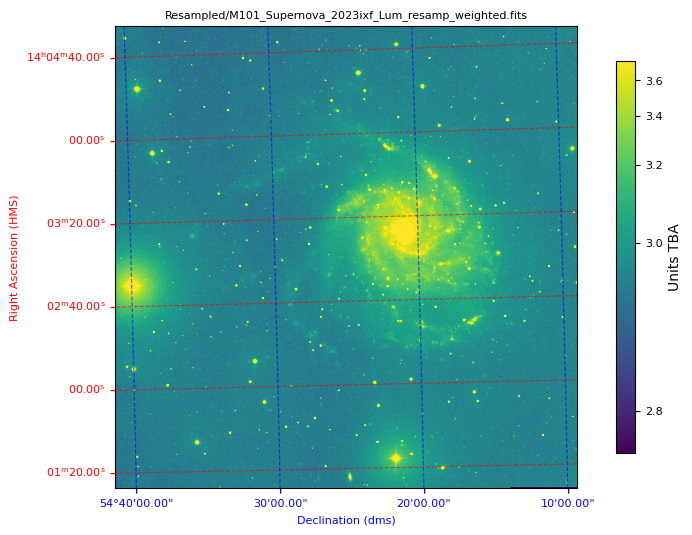

In [21]:
lumf   = resampled_img_dict['Lum']
print(f'Final luminance image: {lumf}')
output_plot = 'luminance_plot.png'
ap.util.load_image_and_plot(lumf, 0, output_plot, True, angle_tick_spacing_am=10, swap_radec_axis=True)

Input red channel data 0.5th percentile = 0.5399, 99.5th percentile = 0.8944
Applying asinh stretch between 0.6000 and 1.6000
--------------------------------------------------------------------------------
WCS for Resampled/M101_Supernova_2023ixf_Red_resamp_weighted.fits:
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 210.754804653 54.4174059435 
CRPIX : 1528.5 1528.5 
PC1_1 PC1_2  : -4.64681630389e-06 0.000175223532872 
PC2_1 PC2_2  : -0.000175223532872 -4.64681630389e-06 
CDELT : 1.0 1.0 
NAXIS : 3056  3056
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
--------------------------------------------------------------------------------
WCS for Resampled/M101_Supernova_2023ixf_Green_resamp_weighted.fits:
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 210.754804653 54.4174059435 
CRPIX : 1528.5 1528.5 
PC1_1 PC1_2  : -4.64681630389e-06 0.000175223532872 
PC2_1 PC2_2  : -0.000175223532872 -4.64681630389e-

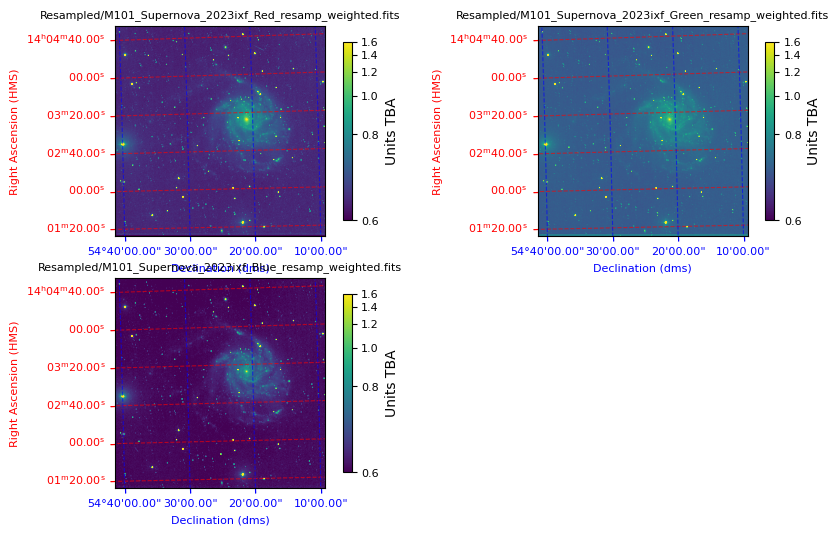

In [22]:
bluef  = resampled_img_dict['Blue']
greenf = resampled_img_dict['Green']
redf   = resampled_img_dict['Red']
valmin  = None
valmax  = None
output_plot = None # Name of output PNG file or None
ap.util.load_three_images_and_plot(redf, greenf, bluef, extnum=0, output=output_plot, 
                                   usewcs=True, vmin=0.6, vmax=1.6, xaxlim=None, 
                                   yaxlim=None, verbose=True, 
                                   angle_tick_spacing_am=10, swap_radec_axis=True)

Blue filter can zoom in to look for the bad pixels that made it through iTelescope's calibration process (here in the resampled luminance image)

Input data 0.5th percentile = 0.5249, 99.5th percentile = 0.8013
Applying asinh stretch between 0.6000 and 1.0000
Using WCS information for axis projection
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 210.754804653 54.4174059435 
CRPIX : 1528.5 1528.5 
PC1_1 PC1_2  : -4.64681630389e-06 0.000175223532872 
PC2_1 PC2_2  : -0.000175223532872 -4.64681630389e-06 
CDELT : 1.0 1.0 
NAXIS : 3056  3056
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [1100, 1500]
Setting Y-axis limits to [350, 750]


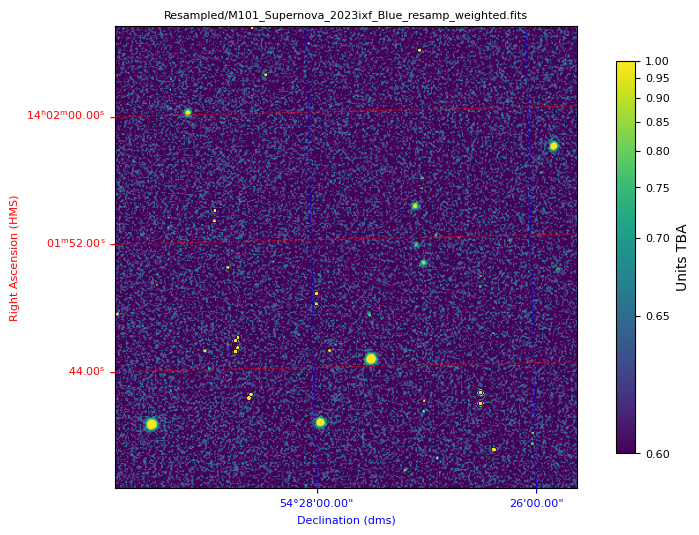

In [23]:
ap.util.load_image_and_plot(bluef, 0, output_plot, True, vmin=0.6, vmax=1.0, xaxlim=[1100, 1500], yaxlim=[350, 750], verbose=True, angle_tick_spacing_am=2, swap_radec_axis=True)

We can use astropy's three-color compositing function

Input red channel data 0.5th percentile = 0.5399, 99.5th percentile = 0.8944
Using an image minimum of 0.5398805156350136 for all channels.
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Wrote plot to M101_lupton_RedGreenBlue.png


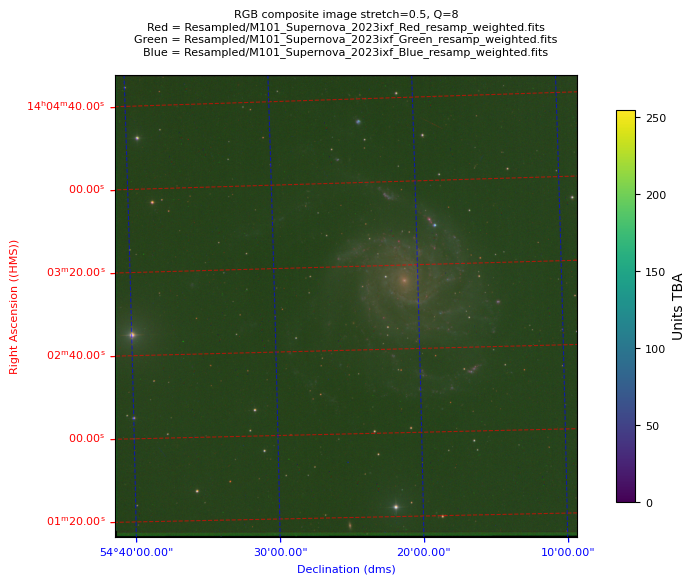

In [24]:
qval    = 8
stretch = 0.5
valmin  = None
outf    = 'M101_lupton_RedGreenBlue.png'
rgb = ap.util.plot_lupton_threecolor(redf, greenf, bluef, outf, 
                                     extnum=0, usewcs=True, vmin=valmin, 
                                     xaxlim=None, yaxlim=None, 
                                     qval=qval, stretchval=stretch, verbose=True, 
                                     angle_tick_spacing_am=10, swap_radec_axis=True)

Or we can use Astromatic `stiff` instead to create a `TIFF` file, and then load and plot that.

**Note:**  this is not wrapped in python yet.

In [25]:
stiff_outputf = 'M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff'
description   = 'M101_Supernova_2023ixf'
user          = 'AstroPhotography'
!stiff $redf $greenf $bluef \
    -OUTFILE_NAME $stiff_outputf -GAMMA_TYPE POWER-LAW -GAMMA 2.2 -GAMMA_FAC 1.0 \
    -COLOUR_SAT 1.0 -MAX_TYPE =QUANTILE,QUANTILE,QUANTILE -MAX_LEVEL 0.999,0.999,0.999 -MIN_TYPE =QUANTILE,QUANTILE,QUANTILE -MIN_LEVEL 0.60,0.60,0.60 \
    -BITS_PER_CHANNEL 8 -VERBOSE_TYPE FULL -DESCRIPTION $description -COPYRIGHT $user -WRITE_XML N


> WARNING: stiff.conf not found, using internal defaults

----- STIFF 2.7.1 started on 2024-11-14 at 21:15:25 with 16 threads

----- Inputs:
M101_Supernova_2023ixf_Red_resamp_weighted.fits: "no ident"  3056x3056   32 bits (floats)
Background level: 0.634998    Min level: 0.618508    Max level: 3.07458   
M101_Supernova_2023ixf_Green_resamp_weighted.fits: "no ident"  3056x3056   32 bits (floats)
Background level: 0.700548    Min level: 0.683503    Max level: 2.88235   
M101_Supernova_2023ixf_Blue_resamp_weighted.fits: "no ident"  3056x3056   32 bits (floats)
Background level: 0.607307    Min level: 0.590825    Max level: 2.50276   

----- Output:
M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff:    3056x3056        3x8  bits (integers) gamma: x1.00  compression: LZW 



Current directory: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
Loading M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff
Plotting full image M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff


Plotting zoomed-in part of M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff
  Note the bad pixels visible in this zoomed-in view.


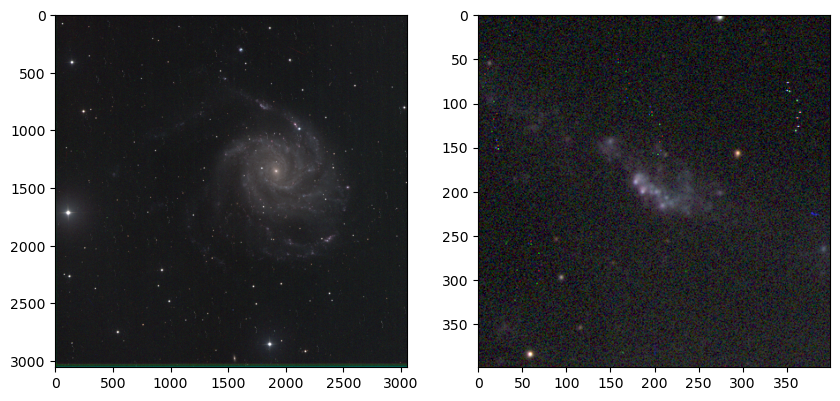

In [26]:
# where are we?
cwd = pathlib.Path('.')
print(f'Current directory: {cwd.resolve()}')
tiff_file = cwd / 'M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff'
if tiff_file.exists():
    fig, (ax1, ax2) = plt.subplots(1,2)
    print(f'Loading {tiff_file.name}')
    tiff_img = plt.imread(tiff_file)
    print(f'Plotting full image {tiff_file}')
    ax1.imshow(tiff_img)

    # Zoom in
    print(f'Plotting zoomed-in part of {tiff_file}')
    print('  Note the bad pixels visible in this zoomed-in view.')
    ax2.imshow(tiff_img[600:1000,1600:2000])    
else:
    print(f'File not found: {tiff_file.name}')
    print('  Skipping display of STIFF generated file...')


Again, on closer inspection the bad pixels are apparent.

The following lines of code make copies of some of these output files, for later comparison to the same product after attempting fix some of the problems we have highlighted.

In [27]:
orig_bluef_path = pathlib.Path(bluef)
new_name = 'orig_' + orig_bluef_path.name
new_resampled_blue_file = orig_bluef_path.with_name(new_name)
print(f'Copying {bluef} to {str(new_resampled_blue_file)}')
copyof_original_bluef = shutil.copyfile(bluef, new_resampled_blue_file)
print(f'Created {copyof_original_bluef}')

orig_tiff_file_path = pathlib.Path(tiff_file)
new_name = 'orig_' + orig_tiff_file_path.name
new_tiff_file = orig_tiff_file_path.with_name(new_name)
print(f'Copying {tiff_file} to {str(new_tiff_file)}')
copyof_original_tiff_file = shutil.copyfile(tiff_file, new_tiff_file)
print(f'Created {copyof_original_tiff_file}')

Copying Resampled/M101_Supernova_2023ixf_Blue_resamp_weighted.fits to Resampled/orig_M101_Supernova_2023ixf_Blue_resamp_weighted.fits
Created Resampled/orig_M101_Supernova_2023ixf_Blue_resamp_weighted.fits
Copying M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff to orig_M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff
Created orig_M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff


In [28]:
# Close all the open figures in memory
plt.close('all')

## Summary

The main processing pathway used in this section, excluding the plotting functions, is basically
```python
loglevel = 'DEBUG'
processor = ap.ApProcess(loglevel)

# Source detection and astrometry
# Set values for:  data_dir, include_pattern, exclude_pattern,  file suffix = '.fits.gz'
#                  quality_summary_file, clean_srclists, clean_navfiles, stop_on_error, quiet
status = processor.navigate_images(data_dir, include_pattern, exclude_pattern, None, None, '.fits.gz', 
                                   quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)

# Load and look at the quality summary file
qual_summ_table = Table.read(quality_summary_file, format="ascii.csv")
qual_summ_table['file', 'ncols','nrows','filter','median','stddev',
    'num_detected','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts'].pprint_all()

# Get a list of navigated files...
navigated_file_list = processor.get_file_names('navfile', data_dir, 'existing', include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
print(f'Navigated image files on disk:  \n{navigated_file_list}')
first_file = navigated_file_list[0]
w, pix_scales, pix_area, im_scales = ap.util.load_wcs_from_file(first_file)
print(f'\nSummarizing WCS information from {f

# Resample and stack images in all the filters
# Set values for target_wcs_file, resam_prefix, resam_suffix, resampled_dir=resam_dir
resampled_img_dict, info_table = processor.resample_images_to_match(target_wcs_file, resam_prefix, resam_suffix, resampled_dir=resam_dir, filter_list=None)

```

# Preprocessing to Fix Bad Pixels and Add Metadata

The previous section demonstrated the use of `ApProcess` to recreate the processing shown in `itelescope_premium-the_hard_way.ipynb`. This section improves on the previous section by applying two pre-processing stages to the calibrated files before navigating them:

1. Add metadata to the iTelescope Premium file headers, both for completeness' sake and to speed up the astrometric solutions.
2. Apply bad pixel, bad column and bad row correction. This will alleviate the issues shown the visualization of the resampled iTelescope premium images shown in Section 2.5.
3. Apply Cosmic Ray rejection. In most cases where bad pixel correction is required it makes sense to perform CR rejection as well after the bad pixel correction.

**Note:** Currently only a metadata dictionary is supported for adding metadata. In the near term a YaML file will also be an option.

## Metadata Dictionary Format

The python dictionary should consist of  `key: (value, comment)` pairs, where `key` and `comment` are strings. The `key` keyword must conform to FITS file convenstions, in particular the keyword cannot be longer than 8 letters, cannot start with a numeral, and cannot include whitespace.

In Section 2, running the iTelescope Plan-30 M101 SN 2023ixf data, we saw that the following keywords were not found in the calibrated input image headers:
```
2024-09-20 09:00:50,425 | AstroPhotography.core.ApFindStars | DEBUG | FITS keywords missing from image: ['EXPOSURE', 'DATE-OBS', 'OBJECT', 'OBJNAME', 'TELESCOP', 'INSTRUME', 'CCD-TEMP', 'RA-OBJ', 'DEC-OBJ', 'XPIXSZ', 'YPIXSZ', 'EGAIN', 'LAT-OBS', 'LONG-OBS', 'ALT-OBS', 'AIRMASS']
```
We are going to specify the values for some of these in the metadata dictionary, based on prior knowledge of the telescope/instrument package used for the observations.  Others, like the date, time, and airmass, we lack the information necessary to determine. 

We could also specify `EXPOSURE` in the metadata dictionary but in practice we know that the header contains one of the commonly used equivalent keywords, so we can tell ApProcess to find it and set `EXPOSURE` to match it.

## Bad Pixel Correction

See the `creating_a_master_bad_pixel_file.ipynb` notebook for details on how to create a master bad pixel / bad row / bad column file.

## Preprocessing File Naming Convention

Preprocessing does not modify the original input files. Instead it creates new files with names based on string replacement of the of original inputs files. The new file names are then either explicitly input as an `input_file_list` when running `navigate_images`, *or* you can modify the `include_pattern`. In both cases the `input_rootname` should be updated.

The diagram below shows a simplified example:

```python
Normal (no-preprocessing) Case                                       Preprocessing Case
------------------------------------------------------               ------------------------------------------------------

data_dir        = r'.'                                               data_dir        = r'.'
include_pattern = "Calibrated-*-?.fits*"                             include_pattern = "Calibrated-*-?.fits*"
exclude_pattern = None                                               exclude_pattern = None
processor       = ap.ApProcess(loglevel)                             processor       = ap.ApProcess(loglevel)


                                                                     preprocess_instr = 'Calibrated'
                                                                     preprocess_outstr = 'recalibrated'
                                                                     modified_files = processor.preprocess_images(data_dir,
                                                                         preprocess_instr, preprocess_outstr, 
                                                                         include_pattern, exclude_pattern, ...)

                                                                     # Then we can either use the modified file list and reset the
                                                                     # input_rootname, e.g.

status          = processor.navigate_images(data_dir,                status = processor.navigate_images(data_dir, include_pattern=None,  
    include_pattern, exclude_pattern, ...)                               input_file_list=modified_files, input_rootname=preprocess_outstr, ...)

                                                                     # OR we can modify the input include_pattern, e.g.
                                                                     modified_pattern = include_pattern.replace(preprocess_instr, preprocess_outstr)
                                                                     print(modified_pattern)     # produces "recalibrated-*-?.fits*"

                                                                     status = processor.navigate_images(data_dir,
                                                                         modified_pattern, exclude_pattern,
                                                                         input_file_list=None, input_rootname=preprocess_outstr, ...)
```

## Run the Preprocessing

*Note:* The following inputs are hard-wired for the iTelescope M101 SN 2023ixf data. 

*Bad Pixel Files:* At the time of writing (2024-10-03) the official T24 calibration files are still December 2021 vintage. The bad pixel file generated from those calibration files is the one pointed to by `old_badpixfile`. Processing using that file generated only partial improvement in the output, so I generated a short series of darks for T24 on 2024-10-01 that were used to generate `new_badpixfile`. This bad pixel file is the one used, and is much more effective at removed bad pixels than the older one.

In [29]:
# switch to control running preprocessing and reprocessing "by hand"
do_by_hand_preprocess = False

In [30]:
# metadata dictionary
meta_dict = {'OBJNAME':  ('M101 Supernova 2023ixf', 'Target'),
             'OBJECT':   ('M101 Supernova 2023ixf', 'Target'),
             'TELESCOP': ('iTelescope 24', 'Telescope name'),
             'INSTRUME': ('FLI-PL09000', 'Instrument name'),
             'XPIXSZ':   (12.0, 'Pixel Width in microns (after binning)'),
             'YPIXSZ':   (12.0, 'Pixel Height in microns (after binning)'),
             'EGAIN':    (1.53, 'Electronic gain in e-/ADU')}

# Overwrite existing header keywords with the same name
rewrite_existing_kw=False

# Set EXPOSURE if not present and any of the other exposure-like FITS keywords are present
find_exposure_time=True

# Bad pixel file location (e.g. creating_a_master_bad_pixel_file.ipynb)
old_badpixfile='/old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'
new_badpixfile='/old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300/master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits'
badpixfile = new_badpixfile

cr_rejection = True

# instr is the part of the original calibrated input file name that will be renamed in the modified,
# preprocessed, output files.
preprocess_instr = 'Calibrated'
preprocess_outstr = 'recalibrated'

In [31]:
del processor
loglevel = 'INFO'
processor = ap.ApProcess(loglevel)

In [32]:
extnum = 0
if do_by_hand_preprocess:
    resampled_files = processor.preprocess_images(
        data_dir,
        preprocess_instr,
        preprocess_outstr,
        include_pattern,
        exclude_pattern,
        None,
        None,
        ".fits.gz",
        extnum=extnum,
        find_exposure_time=find_exposure_time,
        keyword_dict=meta_dict,
        replace_keywords=rewrite_existing_kw,
        badpixelfile=badpixfile,
        fix_cosmic_rays=cr_rejection,
    )

We can inspect the before and after images

In [33]:
masterdarkfile = '/old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'

if do_by_hand_preprocess:
    input_files = processor.get_file_names(process_stage, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
    output_plot = None # Name of output PNG file or None
    ap.util.load_image_and_plot(masterdarkfile, 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)
    ap.util.load_image_and_plot(badpixfile, 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)
    ap.util.load_image_and_plot(input_files[0], 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)
    ap.util.load_image_and_plot(resampled_files[0], 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)
    ap.util.load_image_and_plot(input_files[-3], 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)
    ap.util.load_image_and_plot(resampled_files[-3], 0, output_plot, False, xaxlim=[1100, 1300], yaxlim=[350, 550], verbose=True)

With the more recent bad pixel map the output is very encouraging. In this particular region all the bad pixels were corrected. 

*Side note:* Inspection of the out-of-date master dark file shows the brightest bad pixels in the SN2023ixf data are not active in the 2021-era master dark. Changing the processing parameters used with `ApFindBadPixels` is not going to find those pixels as being bad. Ultimately the problem is that the 2021-era calibration data is not up-to-date. (With the out-of-date bad pixel map the output is disappointing, in that two of the brightest bad pixels are not corrected for in. Only approximately half of the bad pixels were removed.)


## Image Navigation and Resampling on Reprocessed Files

We can proceed with the normal processing using these resampled images. 

In [34]:
if do_by_hand_preprocess:
    # Need to remove existing quality summary table
    pathlib.Path(quality_summary_file).unlink(True)

In [35]:
if do_by_hand_preprocess:
    # OR we can modify the input include_pattern, e.g.
    print(f'preprocess_instr={preprocess_instr}, prepreprocess_outstr={preprocess_outstr}')
    modified_pattern = include_pattern.replace(preprocess_instr, preprocess_outstr)
    print(f'modified_pattern={modified_pattern}')

In [36]:
if do_by_hand_preprocess:
    # Check that processing will pick up the files we used.
    # Show files names that would be generated {'conceptual', 'processed', 'existing'}
    ap_filestate = 'existing'
    
    # Note we need to specify that the input_suffix is 'fits.gz' not for the inputs, which
    # are picked up by the include_pattern, but for the output file types.
    
    process_stage     = 'input'
    no_name_and_dir   = False
    with_name_and_dir = True
    input_files = processor.get_file_names(process_stage, data_dir, ap_filestate, modified_pattern, exclude_pattern, input_file_list=None, input_rootname=preprocess_outstr, 
                                           input_suffix='.fits.gz', name_and_dir=no_name_and_dir)
    for file in input_files:
        print(f'  {file}')

In [37]:
if do_by_hand_preprocess:
    # Compare to files we got from preprocess_images()
    for file in resampled_files:
        print(f'  {file}')

In [38]:
if do_by_hand_preprocess:
    clean_run = True
    if clean_run:
        clean_srclists = True
        clean_navfiles = True
    else:
        clean_srclists = False
        clean_navfiles = False
    
    stop_on_error = False
    quiet = True
    
    status = processor.navigate_images(data_dir, modified_pattern, exclude_pattern, None, preprocess_outstr, '.fits.gz', 
                                       quality_summary_file, clean_srclists, clean_navfiles, stop_on_error=stop_on_error, quiet=quiet)

In [39]:
if do_by_hand_preprocess:
    # show status table
    status.pprint(max_width=200)

**Performance:** Processing all the images sequentially takes about a minute per image, with most of the time taken waiting for `Astrometry.net` to provide the WCS solution.

In [40]:
if do_by_hand_preprocess:
    # Load and display the quality summary table (NOTE this is a very wide table)
    qual_summ_table = Table.read(quality_summary_file, format="ascii.csv")
    # Show some data from the quality summary data.
    qual_summ_table['file', 'ncols','nrows','filter','median','stddev',
        'num_detected','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts'].pprint_all()

In [41]:
if do_by_hand_preprocess:
    target_wcs_file = './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits'
    resam_prefix    = 'M101_Supernova_2023ixf_'
    resam_suffix    = '_resamp_weighted.fits'
    resam_dir       = 'Resampled'
    resampled_img_dict, info_table = processor.resample_images_to_match(target_wcs_file, resam_prefix, resam_suffix, resampled_dir=resam_dir, filter_list=None)

In [42]:
if do_by_hand_preprocess:
    lumf   = resampled_img_dict['Lum']
    print(f'Final luminance image: {lumf}')
    output_plot = 'luminance_plot.png'
    ap.util.load_image_and_plot(lumf, 0, output_plot, True, angle_tick_spacing_am=10, swap_radec_axis=True)

In [43]:
if do_by_hand_preprocess:
    bluef  = resampled_img_dict['Blue']
    greenf = resampled_img_dict['Green']
    redf   = resampled_img_dict['Red']
    valmin  = None
    valmax  = None
    output_plot = None # Name of output PNG file or None
    ap.util.load_three_images_and_plot(redf, greenf, bluef, extnum=0, output=output_plot, 
                                       usewcs=True, vmin=0.6, vmax=1.6, xaxlim=None, 
                                       yaxlim=None, verbose=True, 
                                       angle_tick_spacing_am=10, swap_radec_axis=True)

In [44]:
if do_by_hand_preprocess:
    ap.util.load_image_and_plot(bluef, 0, output_plot, True, vmin=0.6, vmax=1.0, xaxlim=[1100, 1500], yaxlim=[350, 750], verbose=True, angle_tick_spacing_am=2, swap_radec_axis=True)

In [45]:
if do_by_hand_preprocess:
    ap.util.load_image_and_plot(copyof_original_bluef, 0, output_plot, True, vmin=0.6, vmax=1.0, xaxlim=[1100, 1500], yaxlim=[350, 750], verbose=True, angle_tick_spacing_am=2, swap_radec_axis=True)

So, approximately 95% or more of the bad pixels were removed by the preprocessing with the recent dark-file bad pixel map. (Only 50% with the out-of-date bad pixel map.)

In [46]:
if do_by_hand_preprocess:
    qval    = 8
    stretch = 0.5
    valmin  = None
    outf    = 'M101_lupton_RedGreenBlue.png'
    rgb = ap.util.plot_lupton_threecolor(redf, greenf, bluef, outf, 
                                         extnum=0, usewcs=True, vmin=valmin, 
                                         xaxlim=None, yaxlim=None, 
                                         qval=qval, stretchval=stretch, verbose=True, 
                                         angle_tick_spacing_am=10, swap_radec_axis=True)

In [47]:
if do_by_hand_preprocess:
    stiff_outputf = 'M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff'
    description   = 'M101_Supernova_2023ixf'
    user          = 'AstroPhotography'
    !stiff $redf $greenf $bluef \
        -OUTFILE_NAME $stiff_outputf -GAMMA_TYPE POWER-LAW -GAMMA 2.2 -GAMMA_FAC 1.0 \
        -COLOUR_SAT 1.0 -MAX_TYPE =QUANTILE,QUANTILE,QUANTILE -MAX_LEVEL 0.999,0.999,0.999 -MIN_TYPE =QUANTILE,QUANTILE,QUANTILE -MIN_LEVEL 0.60,0.60,0.60 \
        -BITS_PER_CHANNEL 8 -VERBOSE_TYPE FULL -DESCRIPTION $description -COPYRIGHT $user -WRITE_XML N

In [48]:
if do_by_hand_preprocess:
    # where are we?
    cwd = pathlib.Path('.')
    print(f'Current directory: {cwd.resolve()}')
    tiff_file = cwd / 'M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff'
    if tiff_file.exists():
        fig, (ax1, ax2) = plt.subplots(1,2)
        print(f'Loading {tiff_file.name}')
        tiff_img = plt.imread(tiff_file)
        print(f'Plotting full image {tiff_file}')
        ax1.imshow(tiff_img)
    
        # Zoom in
        print(f'Plotting zoomed-in part of {tiff_file}')
        print('  Note the bad pixels visible in this zoomed-in view.')
        ax2.imshow(tiff_img[600:1000,1600:2000])    
    else:
        print(f'File not found: {tiff_file.name}')
        print('  Skipping display of STIFF generated file...')


Compare the old and new TIFF files... The new ones are on the top row and the old ones are on the bottom row.

In [49]:
if do_by_hand_preprocess:
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    print(f'Loading {tiff_file.name}')
    tiff_img = plt.imread(tiff_file)
    print(f'Plotting full image {tiff_file}')
    ax1.imshow(tiff_img)
    ax1.set_title(tiff_file, fontsize=7)
    
    # Zoom in
    print(f'Plotting zoomed-in part of {tiff_file}')
    print('  Note the bad pixels visible in this zoomed-in view.')
    ax2.imshow(tiff_img[600:1000,1600:2000])    
    ax2.set_title('recalibrated image zoom-in', fontsize=7)
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    print(f'Loading {copyof_original_tiff_file}')
    tiff_img = plt.imread(copyof_original_tiff_file)
    print(f'Plotting full image {tiff_file}')
    ax1.imshow(tiff_img)
    ax1.set_title(tiff_file, fontsize=7)
    
    # Zoom in
    print(f'Plotting zoomed-in part of {copyof_original_tiff_file}')
    print('  Note the bad pixels visible in this zoomed-in view.')
    ax2.imshow(tiff_img[600:1000,1600:2000])    
    ax2.set_title('original image zoom-in', fontsize=7)

A significant improvement in this zoomed-in region,with only a hint of some cosmic rays or possibly bad pixels in the green and blue channels.

In [50]:
# Close all the open figures in memory
plt.close('all')

# Batch Processing with a Single Function Call

To further simplify batch processing `ApProcess` provides a function that wraps all the the steps together. So far the processing stages, including preprocessing. **Warning:** This does have an unwieldy number of function parameters.

All the necessary function parameters have been collected and listed below.

In [51]:
del processor

loglevel = 'INFO'
processor = ap.ApProcess(loglevel)

***
Standard input file patterns for iTelescope premium datasets....

In [52]:
# Parameters
data_dir = r'./'

# Make sure to check that your pattern works on the command line using `ls`
default_include_pattern = "Calibrated-*-?.fits*"
default_exclude_pattern = None

***
Code for selecting the specific directory we will process

In [53]:
default_dir = '/old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline'
print(f'Default directory for input files: {default_dir}')

print('Enter the path to the directory containing the premium image set (or return for the default): ')
wdir = input('Image set path:').strip() or default_dir
try:
    os.chdir(wdir.strip())
    print('Switched directory to ' + os.getcwd())
except:
    print(f'Error, os.chdir threw an exception changing to {wdir}')
    print('Check that the path you supplied is a valid filesystem path.')
    raise

print(f'Default include file pattern for input files: {default_include_pattern}')
print(f'Default exclude file pattern for input files: {default_exclude_pattern}')

msg = 'Enter new include input file pattern (or return to accept default pattern)'
include_pattern = input(msg).strip() or default_include_pattern
print(f'Using "{include_pattern}" as the input include file pattern.')

msg = 'Enter new exclude input file pattern (or return to accept default pattern)'
exclude_pattern = input(msg).strip() or default_exclude_pattern
print(f'Using "{exclude_pattern}" as the input exclude file pattern.')

Default directory for input files: /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
Enter the path to the directory containing the premium image set (or return for the default): 


Image set path: 


Switched directory to /old_lnx/home/dks/Downloads/iTelescopeScratch/Plan-20-M101SN-Pipeline
Default include file pattern for input files: Calibrated-*-?.fits*
Default exclude file pattern for input files: None


Enter new include input file pattern (or return to accept default pattern) 


Using "Calibrated-*-?.fits*" as the input include file pattern.


Enter new exclude input file pattern (or return to accept default pattern) 


Using "None" as the input exclude file pattern.


***
Clean up any existing source-detection related quality summary file. Both the master summary and the individual YaML files for each image...

In [54]:
if 'M101' in wdir:
    quality_summary_file = 'quality_summary_M101SN.csv'
    print(f'M101 observations detected, adopted deafult quality summary file name: {quality_summary_file}')
else:
    default_qual_sum = 'quality_summary.csv'
    quality_summary_file = input('Name for final image quality summary CSV (enter for default): ').strip() or default_qual_sum
    print(f'Adopted quality summary file name: {quality_summary_file}')

# Need to remove existing quality summary table, and remove existing per-file quality files.
print('Deleting any existing quality summary file...')
pathlib.Path(quality_summary_file).unlink(True)

# Determine the metadata (quality file) directory name
metadata_dir = processor.get_directories('qualfile', data_dir, False)
print(f'YaML quality metadata files are in {metadata_dir}')

# We know the 
print(f'Deleting any existing quality YaML files in {metadata_dir}')
for file_path in pathlib.Path(metadata_dir).glob("qual*.yaml"):
    print(f'Deleting existing quality file {str(file_path)}')
    file_path.unlink(True)

M101 observations detected, adopted deafult quality summary file name: quality_summary_M101SN.csv
Deleting any existing quality summary file...
YaML quality metadata files are in ./MetaData/
Deleting any existing quality YaML files in ./MetaData/


***
The following settings are for preprocessing. Remember, preprocessing is only advised if you already know that the existing calibration is lacking.

In [55]:
# metadata dictionary
meta_dict = {'OBJNAME':  ('M101 Supernova 2023ixf', 'Target'),
             'OBJECT':   ('M101 Supernova 2023ixf', 'Target'),
             'TELESCOP': ('iTelescope 24', 'Telescope name'),
             'INSTRUME': ('FLI-PL09000', 'Instrument name'),
             'XPIXSZ':   (12.0, 'Pixel Width in microns (after binning)'),
             'YPIXSZ':   (12.0, 'Pixel Height in microns (after binning)'),
             'EGAIN':    (1.53, 'Electronic gain in e-/ADU')}

# Overwrite existing header keywords with the same name
rewrite_existing_kw=False

# Set EXPOSURE if not present and any of the other exposure-like FITS keywords are present
find_exposure_time=True

# Bad pixel file location (e.g. creating_a_master_bad_pixel_file.ipynb)
old_badpixfile='/old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'
new_badpixfile='/old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300/master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits'
badpixfile = new_badpixfile

# instr is the part of the original calibrated input file name that will be renamed in the modified,
# preprocessed, output files.
preprocess_instr = 'Calibrated'
preprocess_outstr = 'recalibrated'

***

Additional settings for image navigation

In [56]:
inp_flist = None
inp_rootname = None
clean_run = False ##True
if clean_run:
    clean_srclists = True
    clean_navfiles = True
else:
    clean_srclists = False
    clean_navfiles = False

stop_on_error = False
quiet = True

# accept the defaults on the other navigation parameters....

***

Resampling and image stacking settings.

In [57]:
target_wcs_file = None
# target_wcs_file = './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits'
resam_prefix = "M101_Supernova_2023ixf_"
resam_suffix = "_resamp_weighted.fits"
resam_dir = "Resampled"
filter_list = None

It is often a good idea top investigate some of the out file names in cases where the input files are preprocessed or have a file prefix other than `cal` or `calibrated` or `Calibrated`. Failure to do so may result in hard to diagnose errors later in processing.

In [58]:
# Full set of ftypes
ftypes = ['srclist', 'regfile', 'plotfile', 'qualfile', 'fwhmplot', 'navfile']

# Shorter subset of the files than must be generated for WCS generated and resampling/stacking to work
#ftypes = ['srclist', 'navfile']

show_files = False
if show_files:
    for ftype in ftypes:
        print(80*'=')
        # Get directory info, relative path or absolute path
        rel_filedir = processor.get_directories(ftype, data_dir, False)
        abs_filedir = processor.get_directories(ftype, data_dir, True)
        print(f'File type {ftype} output directory names:')
        print(f'  Relative path={rel_filedir}\n  Absolute path={abs_filedir}')
        print(80*'-')
        
        # File names, without directory path
        print(f'File type {ftype} output file names (no directory info):')
        ofiles = processor.get_file_names(ftype, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        print(80*'-')
            
        # File names **with** directory path
        print(f'File type {ftype} output file names (including directory):')
        ofiles = processor.get_file_names(ftype, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', with_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')

        # Files that this instance has already processed (without directory)
        print(f'File type {ftype} output file names (no directory info), files that have been processed by this instance:')
        ofiles = processor.get_file_names(ftype, data_dir, 'processed', include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        print(80*'-')

        # File that exist on disk, even if they haven't been processed by this instance
        print(f'File type {ftype} output file names (no directory info), files that exist on disk:')
        ofiles = processor.get_file_names(ftype, data_dir, 'existing', include_pattern, exclude_pattern, None, None, '.fits.gz', no_name_and_dir)
        print(f'  There are {len(ofiles)} files in the file list.')
        for file in ofiles:
            print(f'  {file}')
        
else:
    print(f'File name display disabled. To enable, set show_files=True')

File name display disabled. To enable, set show_files=True


***

Finally, run process all

In [ ]:
nav_stat_tbl, stacked_imlist, stacked_im_tbl, preproc_flist = processor.process_all(
    data_dir,
    include_pattern,
    exclude_pattern,
    input_file_list=inp_flist,
    input_rootname=inp_rootname,
    input_suffix=".fits.gz",
    final_quality_file=quality_summary_file,
    clean_star_detection=clean_srclists,
    clean_astrometry=clean_navfiles,
    stop_on_error=stop_on_error,
    quiet=quiet,
    target_wcs_file=target_wcs_file,
    resampled_file_prefix=resam_prefix,
    resampled_file_suffix=resam_suffix,
    resampled_dir=resam_dir,
    preprocess_replace=preprocess_instr,
    preprocess_with=preprocess_outstr,
    find_exposure_time=True,
    keyword_dict=meta_dict,
    replace_keywords=rewrite_existing_kw,
    badpixelfile=badpixfile,
)

2024-11-14 21:16:23,470 | ApProcess | INFO | Attempting to preprocess FITS files within directory=./
2024-11-14 21:16:23,471 | ApProcess | INFO | Using files that match include_pattern="Calibrated-*-?.fits*"
2024-11-14 21:16:23,471 | ApProcess | INFO | Excluding files that match exclude_pattern="None"
2024-11-14 21:16:25,045 | ApProcess | INFO | There are 12 input files matching the parameters given.
2024-11-14 21:16:25,045 | ApProcess | INFO | Loading extension 0 of FITS file /old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300/master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits
2024-11-14 21:16:25,341 | ApProcess | INFO | Preprocessing input file Calibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz into recalibrated-iTelescope-M101_Supernova_2023ixf-180s-Lum-1.fits.gz
2024-11-14 21:16:25,342 | ApFixBadPixels | INFO | fix_bad_pixels: data has 3056 rows x 3056 columns, dtype=>f4
2024-11-14 21:16:25,342 | ApFixBadPixels | INFO | fix_ba

In [ ]:
# Output files generated by preprocessing
if preproc_flist is not None:
    print('--- Files generated by preprocessing: ---')
    for im in preproc_flist:
        print(f'  {im}')
else:
    print('--- No preprocessing applied. ---')

# show status table
print('--- Navigation status table ---')
nav_stat_tbl.pprint(max_width=200)

# # Load and display the quality summary table (NOTE this is a very wide table)
print('--- Source detection image quality summary table ---')
try:
    qual_summ_table = Table.read(quality_summary_file, format="ascii.csv")
    qual_summ_table['file', 'ncols','nrows','filter','median','stddev', 'num_detected','fwhm_val_pix','fwhm_err_pix','fwhm_val_arcs','fwhm_err_arcs','num_data_pts'].pprint_all()
except:
    print('Quality summary table was not generated')

In [ ]:
# Stacked images etc
print('--- List of stacked/resampled images: ---')
for im in stacked_imlist.items():
    print(f'  {im}')
print('--- Resamplined Image Info Table ---')
stacked_im_tbl.pprint_all()

In [ ]:
# An alternate method of getting the file names at this stage  is to use get_directories() 
# and/or get_file_names() on the preprocessed and resampled files with the ap_filestate='processed'
ap_filestate = 'processed'
name_and_dir = True
for ftype in ['preproc_out', 'resampled']:
    print(80*'-')
    tmp_dir = processor.get_directories(ftype, data_dir, False, resampled_dir=resam_dir)
    print(f'For {ftype} the directory is {tmp_dir}')
    tmp_flist = processor.get_file_names(ftype, data_dir, ap_filestate, include_pattern, exclude_pattern, None, None, '.fits.gz', True)
    print(f'  There are {len(tmp_flist)} files in the file list.')
    for file in tmp_flist:
        print(f'  {file}')    

---
Generate summary plots...

In [ ]:


# target_wcs_file = './NavigatedImages/navigated-M101_Supernova_2023ixf-180s-Lum-1.fits'
# resam_prefix    = 'M101_Supernova_2023ixf_'
# resam_suffix    = '_resamp_weighted.fits'
# resam_dir       = 'Resampled'
# resampled_img_dict, info_table = processor.resample_images_to_match(target_wcs_file, resam_prefix, resam_suffix, resampled_dir=resam_dir, filter_list=None)

# bluef  = resampled_img_dict['Blue']
# greenf = resampled_img_dict['Green']
# redf   = resampled_img_dict['Red']
# valmin  = None
# valmax  = None
# output_plot = None # Name of output PNG file or None
# ap.util.load_three_images_and_plot(redf, greenf, bluef, extnum=0, output=output_plot,
#                                    usewcs=True, vmin=0.6, vmax=1.6, xaxlim=None,
#                                    yaxlim=None, verbose=True,
#                                    angle_tick_spacing_am=10, swap_radec_axis=True)

# qval    = 8
# stretch = 0.5
# valmin  = None
# outf    = 'M101_lupton_RedGreenBlue.png'
# rgb = ap.util.plot_lupton_threecolor(redf, greenf, bluef, outf,
#                                      extnum=0, usewcs=True, vmin=valmin,
#                                      xaxlim=None, yaxlim=None,
#                                      qval=qval, stretchval=stretch, verbose=True,
#                                      angle_tick_spacing_am=10, swap_radec_axis=True)

# stiff_outputf = 'M101_Supernova_2023ixf_RedGreenBlue_resamp_weighted_gf10_cs10_b8.tiff'
# description   = 'M101_Supernova_2023ixf'
# user          = 'AstroPhotography'
# !stiff $redf $greenf $bluef \
#     -OUTFILE_NAME $stiff_outputf -GAMMA_TYPE POWER-LAW -GAMMA 2.2 -GAMMA_FAC 1.0 \
#     -COLOUR_SAT 1.0 -MAX_TYPE =QUANTILE,QUANTILE,QUANTILE -MAX_LEVEL 0.999,0.999,0.999 -MIN_TYPE =QUANTILE,QUANTILE,QUANTILE -MIN_LEVEL 0.60,0.60,0.60 \
#     -BITS_PER_CHANNEL 8 -VERBOSE_TYPE FULL -DESCRIPTION $description -COPYRIGHT $user -WRITE_XML N

# # where are we?
# fig, (ax1, ax2) = plt.subplots(1,2)
# print(f'Loading {tiff_file.name}')
# tiff_img = plt.imread(tiff_file)
# print(f'Plotting full image {tiff_file}')
# ax1.imshow(tiff_img)
# ax1.set_title(tiff_file, fontsize=7)

# # Zoom in
# print(f'Plotting zoomed-in part of {tiff_file}')
# print('  Note the bad pixels visible in this zoomed-in view.')
# ax2.imshow(tiff_img[600:1000,1600:2000])
ax2.set_title("recalibrated image zoom-in", fontsize=7)

# Versions and Changes

| Version | Date | Description |
|:--------|------|-------------|
| 0.5.2-alpha1 | 2024-04-26 | Created script skeleton. |

In [ ]:
# Close all the open figures in memory
plt.close('all')